<a href="https://www.kaggle.com/code/lalit7881/global-corporate-ghg-emissions-2022-23-eda?scriptVersionId=311392770" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/alitaqishah/global-corporate-ghg-emissions-20222023/global_corporate_ghg_emissions_2022_2023.csv


## Laoding dataset

In [2]:
df = pd.read_csv("/kaggle/input/datasets/alitaqishah/global-corporate-ghg-emissions-20222023/global_corporate_ghg_emissions_2022_2023.csv")

In [3]:
df.head()

,company_id,company_name,ticker,country,region,sector,industry,reporting_year,scope1_mt_co2e,scope2_location_mt_co2e,...,scope3_total_mt_co2e,scope1_plus_scope2_location_mt,emissions_intensity_mt_per_musd,revenue_usd_millions,reporting_standard,data_source,third_party_verified,net_zero_target_year,notes,data_collection_date
0,GHG0001,Sasol,SOL,South Africa,Africa,Materials,Chemicals,2022,47.3,2.1,...,NaN,49.4,0.008386,5891.0,GHG Protocol,CDP_2023/SustainabilityReport_2023,True,2050.0,Coal-to-liquid fuel — very high Scope 1,2024-01-01 to 2025-12-31
1,GHG0002,Eskom,—,South Africa,Africa,Utilities,Electric Power,2022,195.0,NaN,...,NaN,195.0,NaN,NaN,GHG Protocol (ZA),SouthAfricaGHGInv_2023,False,NaN,State-owned; coal dominant; financial distress,2024-01-01 to 2025-12-31
2,GHG0003,Woodside Energy,WDS,Australia,Asia-Pacific,Energy,E&P (LNG),2022,7.1,0.5,...,NaN,7.6,0.000452,16816.0,GHG Protocol,NGER_2023/CDP_2023,True,2050.0,NaN,2024-01-01 to 2025-12-31
3,GHG0004,Santos,STO,Australia,Asia-Pacific,Energy,E&P,2022,6.3,0.4,...,NaN,6.7,0.000923,7259.0,GHG Protocol,NGER_2023/CDP_2023,True,2040.0,NaN,2024-01-01 to 2025-12-31
4,GHG0005,BHP,BHP,Australia,Asia-Pacific,Materials,Mining,2022,14.9,3.4,...,NaN,18.3,0.000281,65098.0,GHG Protocol,CDP_2023/SustainabilityReport_2023,True,2050.0,NaN,2024-01-01 to 2025-12-31


In [4]:
df.tail()

,company_id,company_name,ticker,country,region,sector,industry,reporting_year,scope1_mt_co2e,scope2_location_mt_co2e,...,scope3_total_mt_co2e,scope1_plus_scope2_location_mt,emissions_intensity_mt_per_musd,revenue_usd_millions,reporting_standard,data_source,third_party_verified,net_zero_target_year,notes,data_collection_date
503,GHG0504,Pacific Gas & Electric,PCG,United States,North America,Utilities,Electric Power,2022,3.4,0.4,...,NaN,3.8,0.000172,22033.0,GHG Protocol,EPA_GHGRP_2023/CDP_2023,True,2040.0,Mostly hydro/nuclear,2024-01-01 to 2025-12-31
504,GHG0505,Otter Tail Corporation,OTTR,United States,North America,Utilities,Electric Power,2022,2.8,0.1,...,NaN,2.9,0.002929,990.0,GHG Protocol,EPA_GHGRP_2023,True,2035.0,NaN,2024-01-01 to 2025-12-31
505,GHG0506,Consolidated Edison,ED,United States,North America,Utilities,Electric Power,2022,2.1,0.3,...,NaN,2.4,0.000159,15058.0,GHG Protocol,EPA_GHGRP_2023/CDP_2023,True,2040.0,NaN,2024-01-01 to 2025-12-31
506,GHG0507,Avangrid,AGR,United States,North America,Utilities,Gas & Renewables,2022,2.1,0.2,...,NaN,2.3,0.000313,7338.0,GHG Protocol,EPA_GHGRP_2023,True,2035.0,NaN,2024-01-01 to 2025-12-31
507,GHG0508,Eversource Energy,ES,United States,North America,Utilities,Electric Power,2022,1.8,0.1,...,NaN,1.9,0.000201,9440.0,GHG Protocol,EPA_GHGRP_2023,True,2030.0,Mostly hydro/gas dist,2024-01-01 to 2025-12-31


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 508 entries, 0 to 507
Data columns (total 21 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   company_id                       508 non-null    object 
 1   company_name                     508 non-null    object 
 2   ticker                           508 non-null    object 
 3   country                          508 non-null    object 
 4   region                           508 non-null    object 
 5   sector                           508 non-null    object 
 6   industry                         508 non-null    object 
 7   reporting_year                   508 non-null    int64  
 8   scope1_mt_co2e                   508 non-null    float64
 9   scope2_location_mt_co2e          480 non-null    float64
 10  scope2_market_mt_co2e            76 non-null     float64
 11  scope3_total_mt_co2e             23 non-null     float64
 12  scope1_plus_scope2_loc

In [6]:
df.describe()

,reporting_year,scope1_mt_co2e,scope2_location_mt_co2e,scope2_market_mt_co2e,scope3_total_mt_co2e,scope1_plus_scope2_location_mt,emissions_intensity_mt_per_musd,revenue_usd_millions,net_zero_target_year
count,508.000000,508.000000,480.000000,76.000000,23.000000,508.000000,444.000000,444.000000,452.000000
mean,2021.992126,20.066201,1.188854,0.744474,199.978261,21.189528,0.001159,42702.572072,2044.128319
std,0.140220,50.324981,1.712788,1.330270,177.106445,50.746609,0.002147,73407.190047,9.507677
min,2021.000000,0.050000,0.000000,0.000000,3.000000,0.080000,0.000001,480.000000,2025.000000
25%,2022.000000,1.200000,0.300000,0.100000,58.000000,2.000000,0.000076,6951.000000,2035.000000
50%,2022.000000,5.150000,0.600000,0.110000,177.000000,6.200000,0.000389,16563.500000,2050.000000
75%,2022.000000,17.825000,1.400000,0.800000,263.000000,18.825000,0.001213,45111.250000,2050.000000
max,2023.000000,710.000000,18.400000,6.400000,630.000000,718.200000,0.017299,604124.000000,2070.000000


In [7]:
df.isnull().sum()

company_id                           0
company_name                         0
ticker                               0
country                              0
region                               0
sector                               0
industry                             0
reporting_year                       0
scope1_mt_co2e                       0
scope2_location_mt_co2e             28
scope2_market_mt_co2e              432
scope3_total_mt_co2e               485
scope1_plus_scope2_location_mt       0
emissions_intensity_mt_per_musd     64
revenue_usd_millions                64
reporting_standard                   0
data_source                          0
third_party_verified                 0
net_zero_target_year                56
notes                              382
data_collection_date                 0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.dtypes

company_id                          object
company_name                        object
ticker                              object
country                             object
region                              object
sector                              object
industry                            object
reporting_year                       int64
scope1_mt_co2e                     float64
scope2_location_mt_co2e            float64
scope2_market_mt_co2e              float64
scope3_total_mt_co2e               float64
scope1_plus_scope2_location_mt     float64
emissions_intensity_mt_per_musd    float64
revenue_usd_millions               float64
reporting_standard                  object
data_source                         object
third_party_verified                  bool
net_zero_target_year               float64
notes                               object
data_collection_date                object
dtype: object

In [10]:
df.shape

(508, 21)

In [11]:
df.columns

Index(['company_id', 'company_name', 'ticker', 'country', 'region', 'sector',
       'industry', 'reporting_year', 'scope1_mt_co2e',
       'scope2_location_mt_co2e', 'scope2_market_mt_co2e',
       'scope3_total_mt_co2e', 'scope1_plus_scope2_location_mt',
       'emissions_intensity_mt_per_musd', 'revenue_usd_millions',
       'reporting_standard', 'data_source', 'third_party_verified',
       'net_zero_target_year', 'notes', 'data_collection_date'],
      dtype='object')

In [12]:
df.nunique()

company_id                         508
company_name                       508
ticker                             445
country                             46
region                               6
sector                              12
industry                           131
reporting_year                       3
scope1_mt_co2e                     222
scope2_location_mt_co2e             62
scope2_market_mt_co2e               26
scope3_total_mt_co2e                23
scope1_plus_scope2_location_mt     278
emissions_intensity_mt_per_musd    360
revenue_usd_millions               438
reporting_standard                  11
data_source                         28
third_party_verified                 2
net_zero_target_year                14
notes                              113
data_collection_date                 1
dtype: int64

## EDA

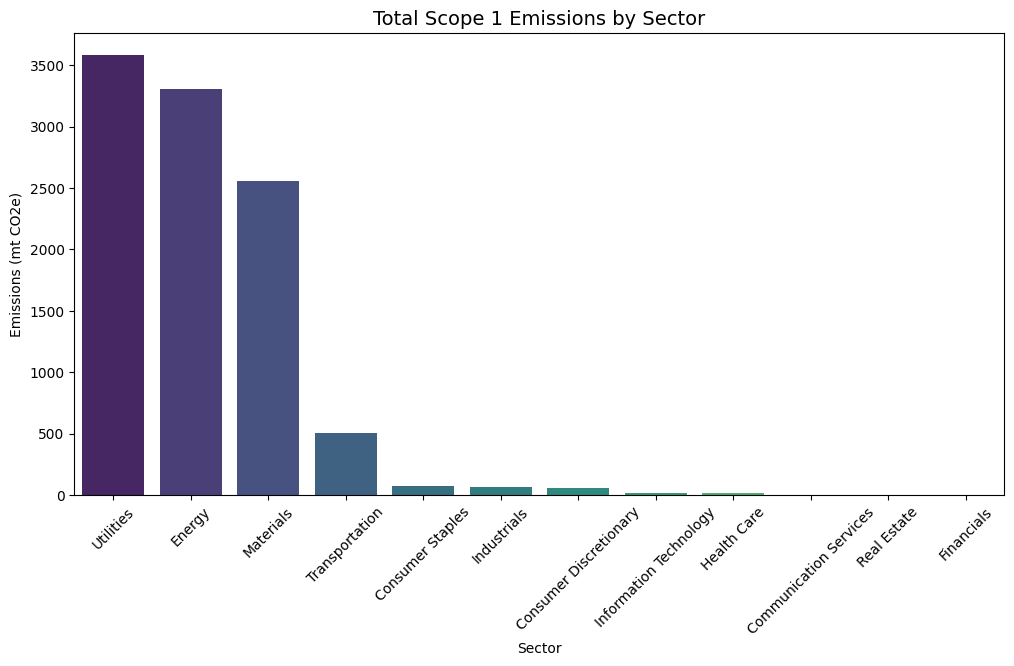

In [13]:
plt.figure(figsize=(12,6))
sector_emissions = df.groupby('sector')['scope1_mt_co2e'].sum().sort_values(ascending=False)

sns.barplot(x=sector_emissions.index, y=sector_emissions.values, palette="viridis")

plt.xticks(rotation=45)
plt.title("Total Scope 1 Emissions by Sector", fontsize=14)
plt.xlabel("Sector")
plt.ylabel("Emissions (mt CO2e)")
plt.show()

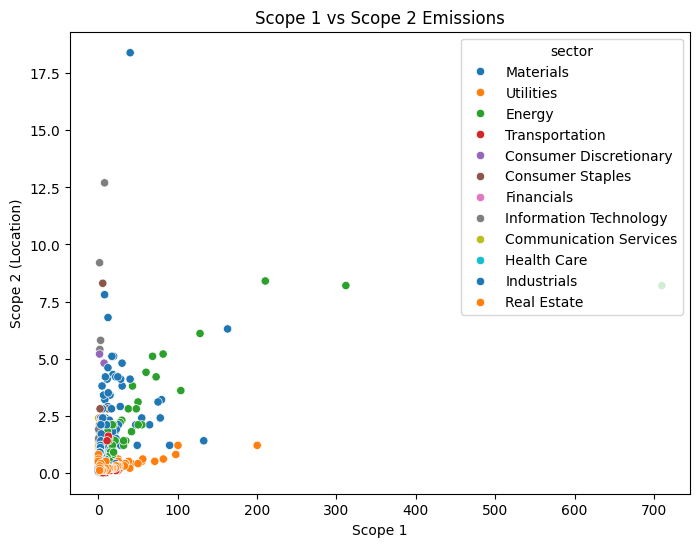

In [14]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x='scope1_mt_co2e',
    y='scope2_location_mt_co2e',
    hue='sector',
    palette="tab10"
)

plt.title("Scope 1 vs Scope 2 Emissions")
plt.xlabel("Scope 1")
plt.ylabel("Scope 2 (Location)")
plt.show()

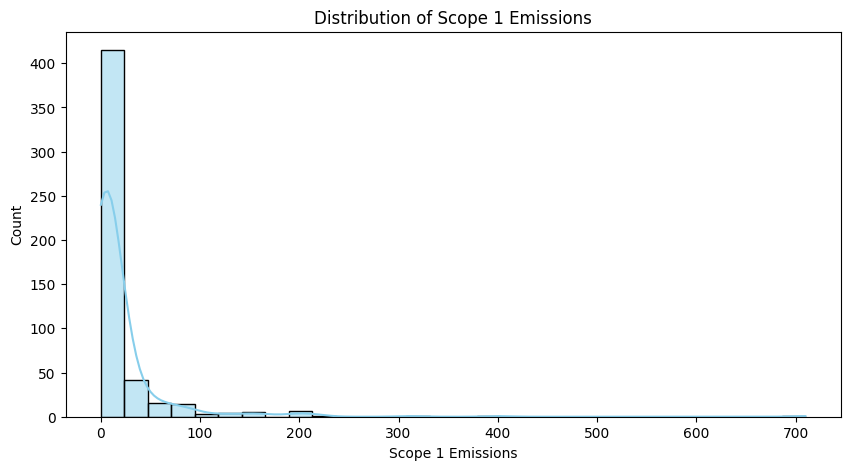

In [15]:
plt.figure(figsize=(10,5))

sns.histplot(df['scope1_mt_co2e'], bins=30, color='skyblue', kde=True)

plt.title("Distribution of Scope 1 Emissions")
plt.xlabel("Scope 1 Emissions")
plt.show()

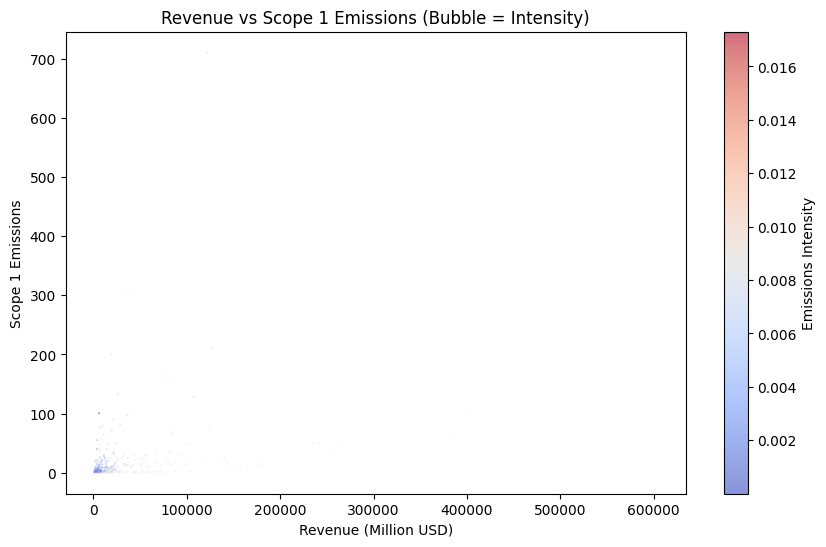

In [16]:
plt.figure(figsize=(10,6))

plt.scatter(
    df['revenue_usd_millions'],
    df['scope1_mt_co2e'],
    s=df['emissions_intensity_mt_per_musd']*10,
    alpha=0.6,
    c=df['emissions_intensity_mt_per_musd'],
    cmap='coolwarm'
)

plt.colorbar(label='Emissions Intensity')
plt.title("Revenue vs Scope 1 Emissions (Bubble = Intensity)")
plt.xlabel("Revenue (Million USD)")
plt.ylabel("Scope 1 Emissions")
plt.show()

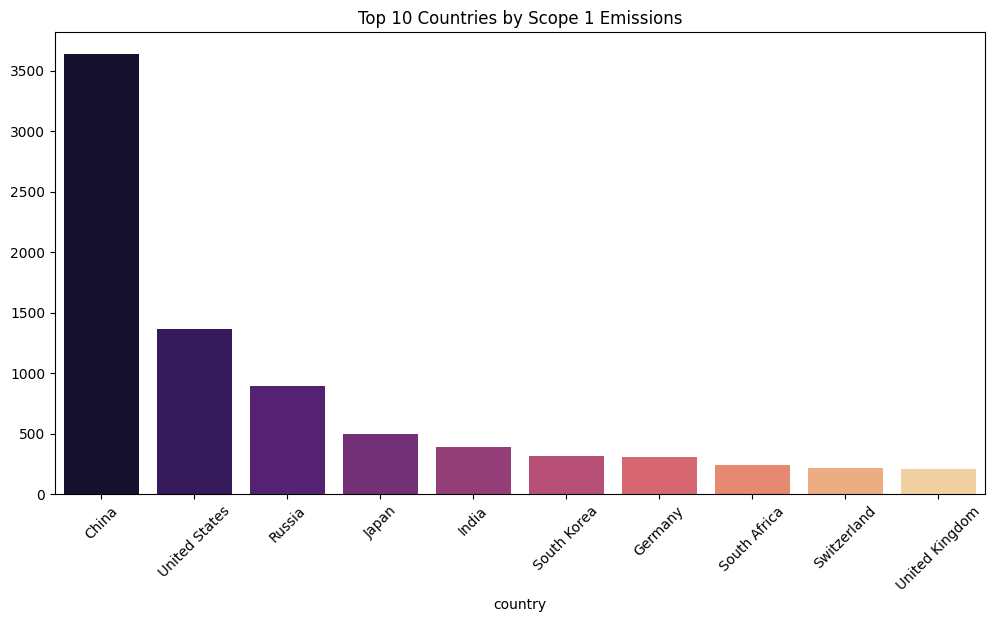

In [17]:
plt.figure(figsize=(12,6))

top_countries = df.groupby('country')['scope1_mt_co2e'].sum().nlargest(10)

sns.barplot(x=top_countries.index, y=top_countries.values, palette="magma")

plt.title("Top 10 Countries by Scope 1 Emissions")
plt.xticks(rotation=45)
plt.show()

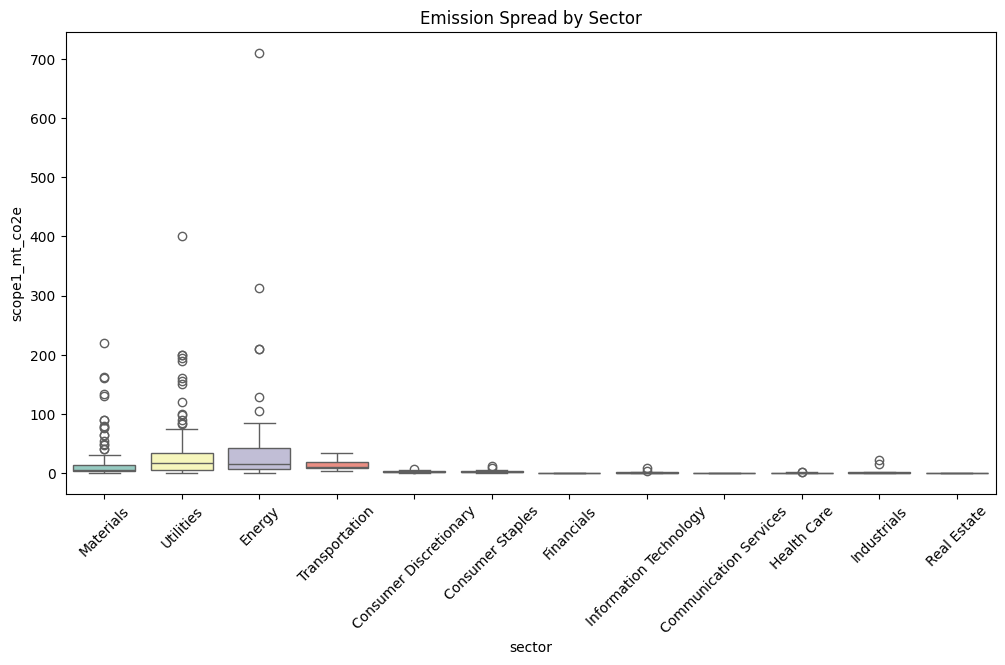

In [18]:
plt.figure(figsize=(12,6))

sns.boxplot(
    data=df,
    x='sector',
    y='scope1_mt_co2e',
    palette="Set3"
)

plt.xticks(rotation=45)
plt.title("Emission Spread by Sector")
plt.show()

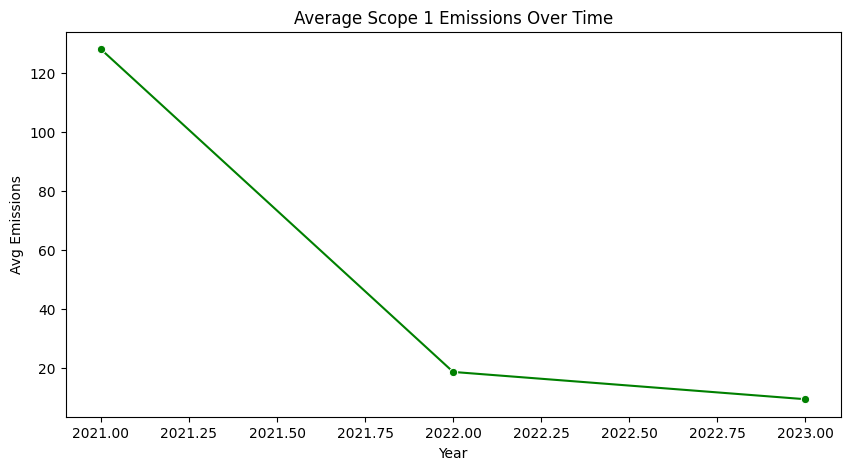

In [19]:
plt.figure(figsize=(10,5))

yearly = df.groupby('reporting_year')['scope1_mt_co2e'].mean()

sns.lineplot(x=yearly.index, y=yearly.values, marker='o', color='green')

plt.title("Average Scope 1 Emissions Over Time")
plt.xlabel("Year")
plt.ylabel("Avg Emissions")
plt.show()

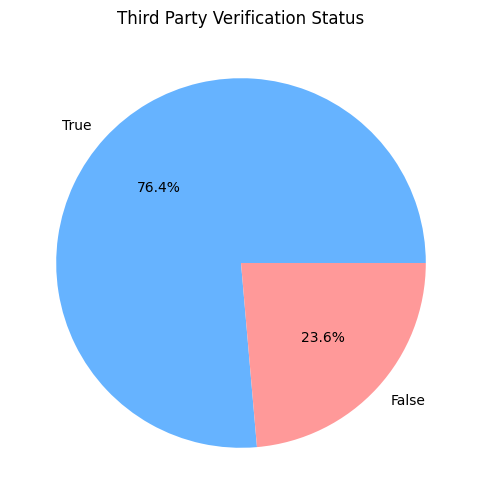

In [20]:
plt.figure(figsize=(6,6))

verification_counts = df['third_party_verified'].value_counts()

plt.pie(
    verification_counts,
    labels=verification_counts.index,
    autopct='%1.1f%%',
    colors=['#66b3ff','#ff9999']
)

plt.title("Third Party Verification Status")
plt.show()

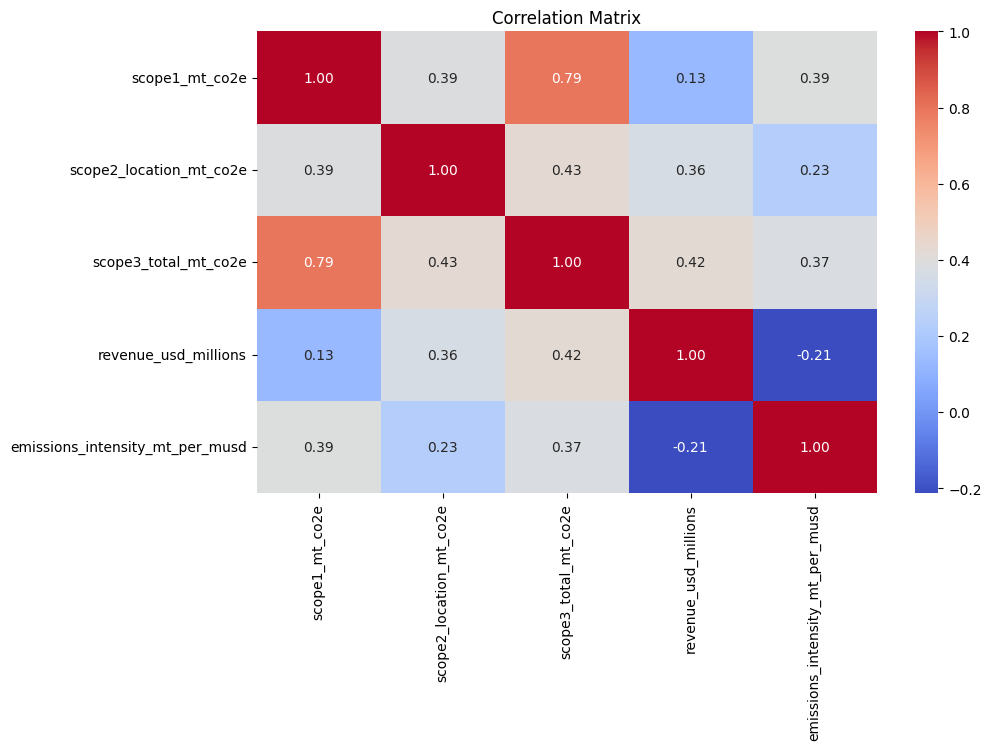

In [21]:
plt.figure(figsize=(10,6))

numeric_cols = [
    'scope1_mt_co2e',
    'scope2_location_mt_co2e',
    'scope3_total_mt_co2e',
    'revenue_usd_millions',
    'emissions_intensity_mt_per_musd'
]

corr = df[numeric_cols].corr()

sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")

plt.title("Correlation Matrix")
plt.show()

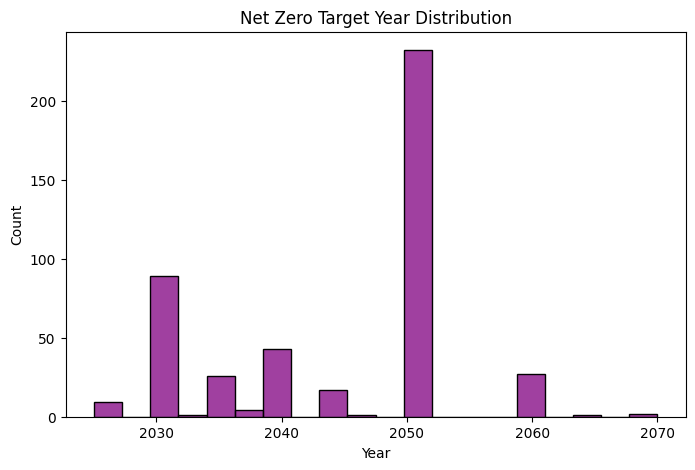

In [22]:
plt.figure(figsize=(8,5))

sns.histplot(df['net_zero_target_year'].dropna(), bins=20, color='purple')

plt.title("Net Zero Target Year Distribution")
plt.xlabel("Year")
plt.show()

## Feature engineering

In [23]:
# Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Metrics
from sklearn.metrics import accuracy_score, classification_report, roc_curve, auc

In [24]:
median_value = df['scope1_mt_co2e'].median()

df['target'] = (df['scope1_mt_co2e'] > median_value).astype(int)

In [25]:
leakage_cols = [
    'scope1_mt_co2e',  # used to create target
    'scope1_plus_scope2_location_mt'
]

df = df.drop(columns=leakage_cols)

In [26]:
X = df.drop(columns=['target'])
y = df['target']

In [27]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [28]:
cat_cols = X_train.select_dtypes(include=['object']).columns

encoders = {}

for col in cat_cols:
    le = LabelEncoder()
    X_train[col] = le.fit_transform(X_train[col].astype(str))
    
    # Handle unseen labels safely
    X_test[col] = X_test[col].astype(str).map(
        lambda s: le.transform([s])[0] if s in le.classes_ else -1
    )
    
    encoders[col] = le

In [29]:
X_train = X_train.fillna(X_train.median(numeric_only=True))
X_test = X_test.fillna(X_train.median(numeric_only=True))

In [30]:
scaler = StandardScaler()

num_cols = X_train.select_dtypes(include=np.number).columns

X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

In [31]:
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [32]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [33]:
# Logistic Regression
lr_pred = lr_model.predict(X_test)
lr_acc = accuracy_score(y_test, lr_pred)

# Random Forest
rf_pred = rf_model.predict(X_test)
rf_acc = accuracy_score(y_test, rf_pred)

print("Logistic Regression Accuracy:", lr_acc)
print("Random Forest Accuracy:", rf_acc)

Logistic Regression Accuracy: 0.7450980392156863
Random Forest Accuracy: 0.8333333333333334


In [34]:
print("Logistic Regression Report:\n", classification_report(y_test, lr_pred))
print("Random Forest Report:\n", classification_report(y_test, rf_pred))

Logistic Regression Report:
               precision    recall  f1-score   support

           0       0.74      0.76      0.75        51
           1       0.76      0.73      0.74        51

    accuracy                           0.75       102
   macro avg       0.75      0.75      0.74       102
weighted avg       0.75      0.75      0.75       102

Random Forest Report:
               precision    recall  f1-score   support

           0       0.87      0.78      0.82        51
           1       0.80      0.88      0.84        51

    accuracy                           0.83       102
   macro avg       0.84      0.83      0.83       102
weighted avg       0.84      0.83      0.83       102



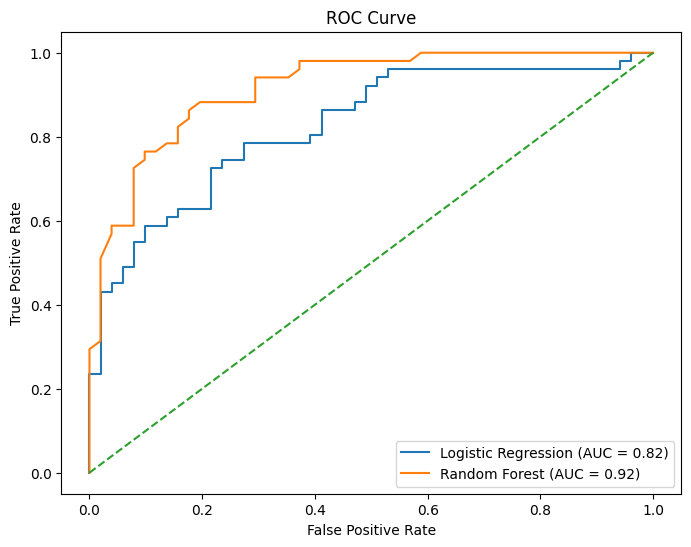

In [35]:
# Probabilities
lr_probs = lr_model.predict_proba(X_test)[:, 1]
rf_probs = rf_model.predict_proba(X_test)[:, 1]

# ROC
lr_fpr, lr_tpr, _ = roc_curve(y_test, lr_probs)
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_probs)

# AUC
lr_auc = auc(lr_fpr, lr_tpr)
rf_auc = auc(rf_fpr, rf_tpr)

# Plot
plt.figure(figsize=(8,6))

plt.plot(lr_fpr, lr_tpr, label=f'Logistic Regression (AUC = {lr_auc:.2f})')
plt.plot(rf_fpr, rf_tpr, label=f'Random Forest (AUC = {rf_auc:.2f})')

plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

## THank you....pls upvote!!!!!!!!!!!